## Metod potpornih vektora (eng. *Support Vector Machine, SVM*)

Ideja je pronaći pravu (ili u više dimenzija hiperravan) koja razdvaja podatke iz dve klase. Takvih razdvajajućih hiperravni ima više, treba izabrati optimalnu - onu koja se nalazi na bezbednom rastojanju i od jedne, i od druge klase, tj. onu hiperravan koja ima najdeblju *marginu*. 

Optimalna razdvajajuća hiperravan, odnosno hiperravan koja ima najdeblju marignu, podjednako je udaljena od najbližih instanci obe klase. Te instance se nazivaju *potporni vektori* pošto pružaju potporu datom sistemu od tri hiperravni - optimalne hiperravni i dve njoj paralelne hiperravni koje određuju marginu. Po njima je ova metoda i dobila ime.

<img src="assets/svm.png" width="70%">

Ako podaci nisu u potpunosti linearno razdvojivi, ali je hiperravan i dalje ugrubo dobar oblik granice između kalsa, tada koristimo *meku marginu* - dopuštamo da se neke instance nađu sa pogrešne strane granice. Ako podaci nisu uopšte linearno razdvojivi, koristimo kernele.

### Pojam kernela

Za svaki kernel $k$ postoji presliakvanje $\Phi_k : X \rightarrow H_k$ skupa $X$ u neki Hilbertov prostor $H_k$ (vektorski prostor sa skalarnim proizvodom) tako da važi $k(x, x') = \phi_k (x) \cdot \phi_k (x')$ gde $\cdot$ označava skalarni proizvod u prostoru $H_k$. Drugim rečima, svaki kernel se može posmatrati kao skalarni proizvod u nekom vektorskom prostoru. Kako svaki skalarni proizvod indukuje meru sličnosti, kernel možemo interpretirati i kao **meru sličnosti** nad polaznim prostorom $X$ (prostor ulaznih atributa).

Neki od najčešće korišćenih kernela su:
- linearni kernel $\hspace{0.2cm}k(x, x') = x^Tx' + c$ (za $c=0$ dobija se običan skalarni proizvod)
- polinomijalni kernel $k(x, x') = (\alpha x^T x' + c)^d$. 
- sigmoidni kernel $\hspace{0.2cm}k(x, x') = tanh(\alpha x^Tx' + c)$
- Gausov ili RBF (eng. *Radial Basis Function*) kernel $\hspace{0.2cm}k(x, x') = e^{-\gamma ||x - x'||^2}$

U najvećem broju slučajeva u radu sa kernelima eksplicitna forma funkcije $\phi_k$ nam nije potrebna, već je dovoljno da na svakom mestu gde se (u modelu) koristi skalarni proizvod zamenimo kernelom. Na taj način postižemo to da skalarni proizvod umesto u prostoru $X$ izračunavamo u odgovarajućem Hilbertovom prostoru $H_k$,

### Linearni i kernelizovani SVM model

Sam SVM model je formalno izražen u terminima skalarnog proizvoda sa potpornim vektorima, koji određuju optimalnu razdvajajuću hiperravan. Osnovni SVM model se još naziva *linearnim SVM modelom* s obzirom da kao meru sličnosti između instanci koristi linearni kernel.

Zamenom skalarnog proizvoda kernelom, dobijamo *kernelizovani SVM model*. Korišćenjem kernela umesto skalarnog proizvoda postižemo da se optimalna razdvajajuća hiperravan umesto u polaznom prostoru sada traži u odgovarajućem Hilbertovom prostoru $H_k$, u kome su podaci vrlo često linearno separabilni (za pogodno odabrani kernel).

### Primer 

Vršimo poređenje linearnog i kernelizovanog modela na primeru podataka sa kružnom granicom između klasa.

In [1]:
import numpy as np

In [2]:
num_instances = 1000
X = np.random.uniform(low=-1, high=1, size=(num_instances, 2))

Generišemo instance tako da je jedna klasa unutar kruga, a druga van.

In [3]:
def f(x, y):
    return x**2 + y**2 <= 0.5

In [4]:
y = f(X[:,0], X[:,1])

In [5]:
from matplotlib import pyplot as plt

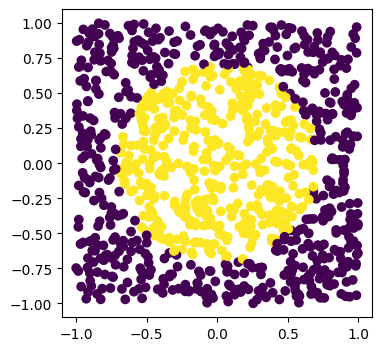

In [6]:
plt.figure(figsize=(4, 4))
plt.scatter(X[:,0], X[:,1], c=y)

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=123)

#### Linearni SVM model

In [9]:
from sklearn.svm import SVC

In [10]:
model = SVC(kernel='linear')                       #IInačin: sklearn.svm.LinearSVC()

In [11]:
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
model.score(X_train, y_train)

0.5893333333333334

In [13]:
model.score(X_test, y_test)

0.588

Očekivano, linearni SVM ne može da nađe pogodnu granicu između klasa jer je prava granica nelinearna.

#### Kernelizovani SVM model

In [14]:
model = SVC(kernel='rbf')

In [15]:
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
model.score(X_train, y_train)

0.9906666666666667

In [17]:
model.score(X_test, y_test)

0.972

In [18]:
print(f'Broj potpornih vektora za svaku od klasa: {model.n_support_}')
print(f'Indeksi instanci koje su potporni vektori: {model.support_}')
print(f'Sami potporni vektori: {model.support_vectors_}')

Broj potpornih vektora za svaku od klasa: [82 79]
Indeksi instanci koje su potporni vektori: [  2  32  34  42  52  53  66  67  81  93 100 116 117 118 126 127 131 141
 148 155 179 190 203 206 216 243 246 250 253 257 264 269 283 284 289 307
 328 336 338 347 368 370 375 376 379 420 424 425 430 441 449 474 483 489
 493 497 498 521 527 535 548 552 553 562 563 568 569 571 581 592 593 642
 647 648 654 661 673 679 690 696 727 741   5  18  23  25  26  41  55  57
  59  70  73 110 114 124 130 143 163 164 172 180 185 192 208 209 221 234
 237 239 242 247 274 303 310 318 332 334 357 364 371 381 386 394 400 447
 452 468 475 476 485 494 499 501 503 510 513 525 537 538 543 544 559 584
 591 596 598 607 618 636 640 641 652 660 668 681 695 717 719 724 731]
Sami potporni vektori: [[ 0.61324089 -0.4673598 ]
 [ 0.42697953 -0.62633106]
 [-0.71944903  0.09930878]
 [ 0.7539006  -0.2303301 ]
 [-0.67859402 -0.366876  ]
 [ 0.73187891  0.35861885]
 [-0.73694188  0.01885541]
 [-0.34459843  0.71125476]
 [-0.01268152 

Iscrtavamo ponovo skup podataka zajedno sa istaknutim potpornim vekorima dobijenog modela.

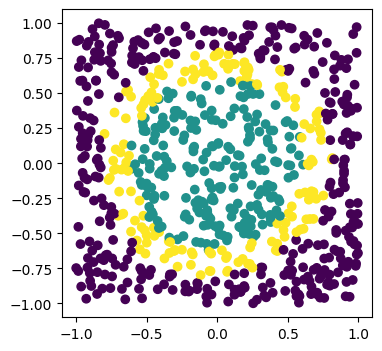

In [19]:
plt.figure(figsize=(4, 4))
color = y_train.astype(int)
color[model.support_] = 2
plt.scatter(X_train[:,0], X_train[:,1], c=color)
plt.show()

### Vizuelizacija podataka u odgovarjaućem prostoru veće dimenzije

In [20]:
def plot_3d(x, y, z, c, elev, azim):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.view_init(elev=elev, azim=azim)
    ax.scatter(x, y, z, c=c)
    plt.show()

#### Vizuelizacija za Gausov kernel

$\hspace{0.2cm}k_{rbf}(x, 0) = e^{-\gamma ||x||^2}$

In [21]:
def visualize_rbf(X, y, gamma=1):
    z = np.exp(-gamma * (X**2).sum(1))
    plot_3d(X[:,0], X[:,1], z, c=y, elev=0, azim=30)

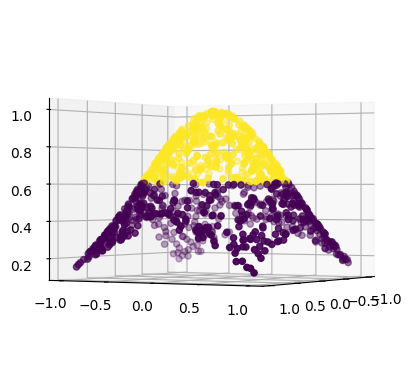

In [22]:
visualize_rbf(X, y)

#### Vizuelizacija za polinomijalni kernel

 $k_{poly}(x, x') = (x \cdot x')^2$

Znamo da svaki kernel predstavlja skalarni proizvod u nekom transformisanom prostoru $k(x, x') = \phi(x) \cdot \phi(x')$. 

Posmatrajmo preslikavanje $\phi : R^2 \rightarrow R^3$ koje svakom vektoru $x = (x_1, x_2)$ pridruzuje vektor $(x_1^2, \sqrt{2}x_1x_2, x_2^2)$. Primetimo da važi sledeće:

$\phi(x) \cdot \phi(x') = (x_1^2, \sqrt{2}x_1x_2, x_2^2) \cdot ({x'}_1^2, \sqrt{2}{x'}_1{x'}_2, {x'}_2^2)$

$\hspace{2.4cm} = x_1^2{x'}_1^2 + 2 x_1x_2{x'}_1{x'}_2 + x_2^2{x'}_2^2$ 

$\hspace{2.4cm} = (x_1{x'}_1 + x_2{x'}_2)^2$

$\hspace{2.4cm} = ((x_1, x_2) \cdot ({x'}_1, {x'}_2))^2$

$\hspace{2.4cm} = (x \cdot x')^2$

$\hspace{2.4cm} = k(x, x')$

Dakle, preslikavanje $\phi$ je upravo to preslikavanje koje kernel $k_{poly}$ 'prevodi' u skalarni proizvod.

Iiscrtavamo vrednosti naših instanci u $3d$ prostoru nakon primene funkcije $\phi$.

In [23]:
def visualize_poly(X, y):
    plot_3d(X[:,0]**2, np.sqrt(2)*X[:,0]*X[:,1], X[:,1]**2, c=y, elev=0, azim=60)

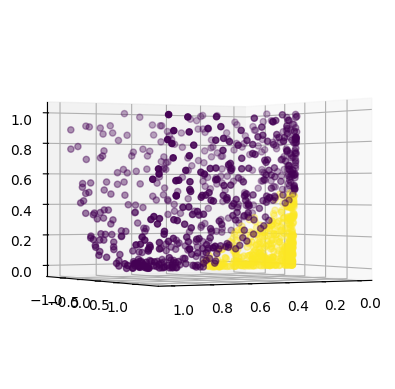

In [24]:
visualize_poly(X, y)

Možemo zaključiti da nam je preslikavanje $\phi$ pomoglo da skup kružno raspoređenih tačaka koji nije bio linearno separabilan transformišemo u linearno separabilan skup u prostoru veće dimenzije.